In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip "/content/drive/MyDrive/AI Ml folder/Copy of FruitinAmazon.zip" -d "/content/drive/MyDrive/AI Ml folder"

unzip:  cannot find or open /content/drive/MyDrive/AI Ml folder/Copy of FruitinAmazon.zip, /content/drive/MyDrive/AI Ml folder/Copy of FruitinAmazon.zip.zip or /content/drive/MyDrive/AI Ml folder/Copy of FruitinAmazon.zip.ZIP.


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

In [4]:
# Define dataset paths
train_dir = "/content/drive/MyDrive/AI Ml folder/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI Ml folder/FruitinAmazon/test"

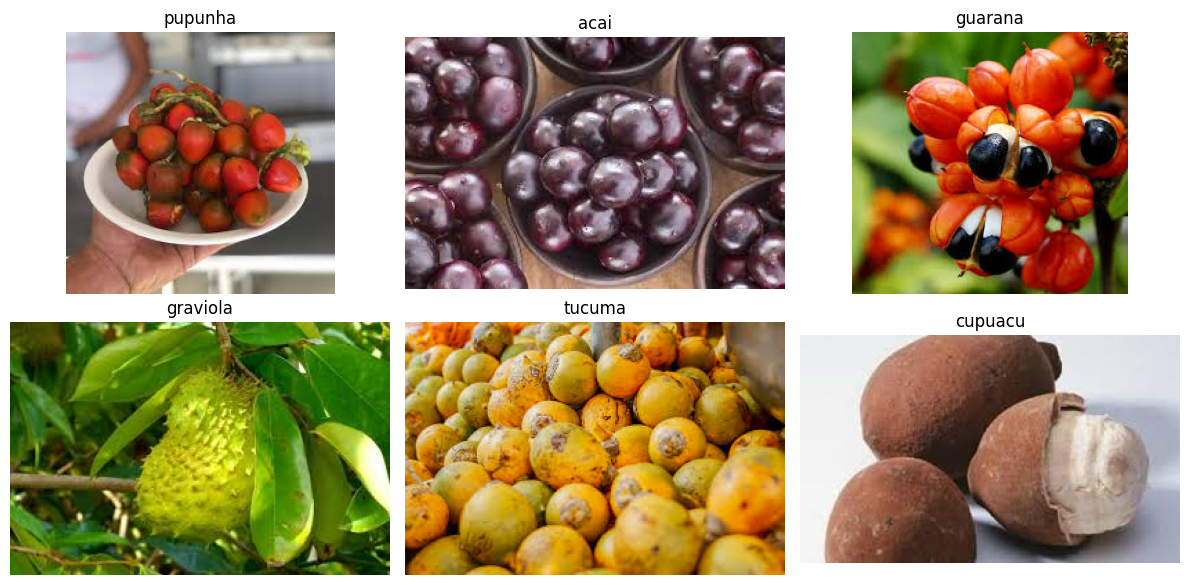

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# Path to your training directory
train_dir = "/content/drive/MyDrive/AI Ml folder/FruitinAmazon/train"

# Get class directories
classes = [cls for cls in os.listdir(train_dir)
           if os.path.isdir(os.path.join(train_dir, cls))]

# Select one random image from each class
images = []
labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    files = os.listdir(class_path)
    if len(files) == 0:
        continue

    img_file = random.choice(files)
    img_path = os.path.join(class_path, img_file)

    img = cv2.imread(img_path)
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert for matplotlib

    images.append(img)
    labels.append(cls)

# Display in grid (2 rows)
num_images = len(images)
cols = (num_images + 1) // 2  # calculate columns for 2 rows

plt.figure(figsize=(12, 6))

for i in range(num_images):
    plt.subplot(2, cols, i + 1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
from PIL import Image

# Path to your dataset
train_dir = "/content/drive/MyDrive/AI Ml folder/FruitinAmazon/train"

corrupted_images = []

# Iterate through each class folder
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    for filename in os.listdir(class_path):
        image_path = os.path.join(class_path, filename)

        try:
            # Try opening and verifying the image
            with Image.open(image_path) as img:
                img.verify()  # checks if image is broken

        except (IOError, SyntaxError):
            # If corrupted → remove it
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")

# Final report
print("\nTotal corrupted images removed:", len(corrupted_images))


Total corrupted images removed: 0


In [ ]:
import tensorflow as tf
# Define image size and batch size
img_height = 128 # Example image height
img_width = 128 # Example image width
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation
# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]
# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
train_dir,
labels='inferred',
label_mode='int',
image_size=(img_height, img_width),
interpolation='nearest',
batch_size=batch_size,
shuffle=True,
validation_split=validation_split,
subset='training',
seed=123
)
# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
train_dir,
labels='inferred',
label_mode='int',
image_size=(img_height, img_width),
interpolation='nearest',
batch_size=batch_size,
shuffle=False,
validation_split=validation_split,
subset='validation',
seed=123
)
# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [ ]:
# Create test dataset with normalization
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)
# Apply the normalization (Rescaling) to the test dataset
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 30 files belonging to 6 classes.


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(img_height, img_width, 3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(6, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer="adam",

loss="sparse_categorical_crossentropy", # labels are in integer
metrics=["accuracy"])

In [ ]:
print("Number of training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Number of validation batches:", tf.data.experimental.cardinality(val_ds).numpy())

# Get one batch from train_ds to inspect shapes
for image_batch, label_batch in train_ds.take(1):
    print("Shape of training image batch (x_train representation):", image_batch.shape)
    print("Shape of training label batch (y_train representation):", label_batch.shape)

# Get one batch from val_ds to inspect shapes
for image_batch, label_batch in val_ds.take(1):
    print("Shape of validation image batch (x_test representation):", image_batch.shape)
    print("Shape of validation label batch (y_test representation):", label_batch.shape)


Number of training batches: 3
Number of validation batches: 1
Shape of training image batch (x_train representation): (32, 128, 128, 3)
Shape of training label batch (y_train representation): (32,)
Shape of validation image batch (x_test representation): (18, 128, 128, 3)
Shape of validation label batch (y_test representation): (18,)


In [ ]:
callbacks = [
  tf.keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
  tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4 ),
]
history = model.fit(
    train_ds,
    epochs=250,
    callbacks=callbacks,
    validation_data=val_ds
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 720ms/step - accuracy: 0.1667 - loss: 1.9540 - val_accuracy: 0.0000e+00 - val_loss: 2.0337
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 644ms/step - accuracy: 0.4028 - loss: 1.6862 - val_accuracy: 0.0000e+00 - val_loss: 1.8719
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 533ms/step - accuracy: 0.5694 - loss: 1.5618 - val_accuracy: 0.0556 - val_loss: 1.8816
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 577ms/step - accuracy: 0.7222 - loss: 1.2967 - val_accuracy: 0.1111 - val_loss: 2.0478
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 780ms/step - accuracy: 0.7083 - loss: 0.9927 - val_accuracy: 0.3333 - val_loss: 1.2032
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.7222 - loss: 0.7938 - val_accuracy: 0.5556 - val_loss: 1.2292
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 601ms/step - accuracy: 0.7639 - loss: 0.6954 - val_accuracy: 0.4444 - val_loss: 1.0347
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 512ms/step - accuracy: 0.7639 - loss: 0.6161 - val_accuracy: 0.888

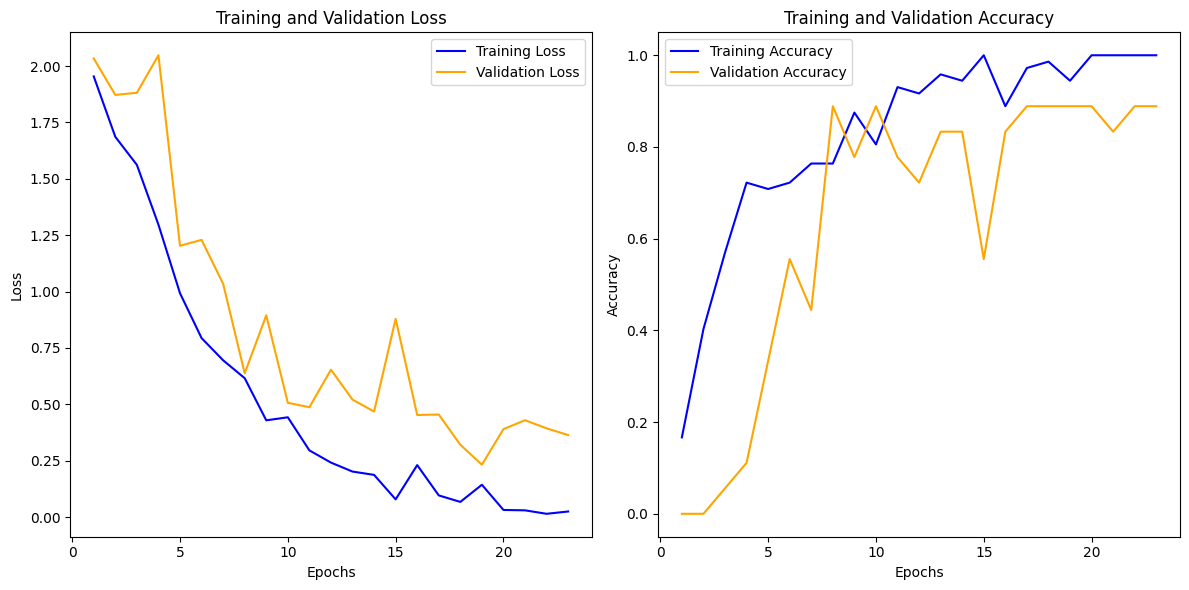

In [ ]:
import matplotlib.pyplot as plt
# Assuming ’history’ is the object returned by model.fit()
# Extracting training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']
# Extracting training and validation accuracy (if metrics were specified)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
# Plotting training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss', color='blue')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.7000 - loss: 1.1614
Test accuracy: 0.7000


In [ ]:
model.save('workshop5.h5')

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Make predictions on the test set
predictions = model.predict(test_ds)

# Convert probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get true labels from the test dataset
true_labels = np.concatenate([y for x, y in test_ds], axis=0)

# Use the 'classes' variable which contains the class names
# This variable was created earlier by listing subdirectories of the training folder.
class_names = classes

# Generate and print the classification report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step
Classification Report:
              precision    recall  f1-score   support

     pupunha       0.75      0.60      0.67         5
        acai       0.42      1.00      0.59         5
     guarana       1.00      0.60      0.75         5
    graviola       1.00      0.60      0.75         5
      tucuma       0.83      1.00      0.91         5
     cupuacu       1.00      0.40      0.57         5

    accuracy                           0.70        30
   macro avg       0.83      0.70      0.71        30
weighted avg       0.83      0.70      0.71        30

